<a href="https://colab.research.google.com/github/hanidew/G12_IR_Evaluation/blob/Significant_Testing/IRWS_Significant_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Link Google Colab with my google drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **A Paired Samples t-test will be conducted across all 15 systems, which will result in 105 unique system-pair comparisons.**

In [ ]:
import pandas as pd
from scipy import stats
import itertools

# 1. SETUP FILE PATHS
input_file_path = '/content/drive/MyDrive/IRWS/set12/P@10.csv'

# Saving the file inside my Gdrive
output_file_path = input_file_path.replace('P@10.csv', 'Significance_Testing_Results.csv')

# 2. LOAD THE DATA
print("Loading data...")
# index_col=0 ensures the 'Topic' column acts as the row labels, not as a system score
df = pd.read_csv(input_file_path, index_col=0)

# Extract the 15 system names from the columns
systems = df.columns.tolist()

# 3. GENERATE THE 105 MATCHUPS
system_pairs = list(itertools.combinations(systems, 2))
print(f"Total systems loaded: {len(systems)}")
print(f"Total pairs to test: {len(system_pairs)}\n")

# 4. RUN THE PAIRED T-TEST
significant_pairs_count = 0
results_list = []

print("Running paired t-tests on all 105 matchups...")
for sysA, sysB in system_pairs:
    # Get the 50 scores for each system
    scores_A = df[sysA]
    scores_B = df[sysB]

    # Run the statistical test
    t_stat, p_value = stats.ttest_rel(scores_A, scores_B)

    # Is the Luck Index (p-value) less than 5%?
    is_significant = p_value < 0.05

    if is_significant:
        significant_pairs_count += 1

    # Log the result for this specific matchup
    results_list.append({
        'System_A': sysA,
        'System_B': sysB,
        'T-Statistic': round(t_stat, 4),
        'P-Value': p_value,
        'Significant (p<0.05)': is_significant
    })

# 5. SAVE AND DISPLAY RESULTS
# Convert log into a clean table (DataFrame)
df_results = pd.DataFrame(results_list)

# Save it directly back to Google Drive
df_results.to_csv(output_file_path, index=False)

# Print final answer
print("\n========== SIGNIFICANCE TEST RESULTS ==========")
print(f"Out of {len(system_pairs)} pairs, {significant_pairs_count} pairs are significantly different.")
print("===============================================\n")

print(f"Success! A detailed breakdown of all 105 matchups has been saved to your Drive at:")
print(output_file_path)

Loading data...
Total systems loaded: 15
Total pairs to test: 105

Running paired t-tests on all 105 matchups...

========== SIGNIFICANCE TEST RESULTS ==========
Out of 105 pairs, 43 pairs are significantly different.

Success! A detailed breakdown of all 105 matchups has been saved to your Drive at:
/content/drive/MyDrive/IRWS/set12/Significance_Testing_Results.csv


**1. What does the "TRUE" mean?**

If a row says TRUE, it means the p-value is less than 0.05 (significantly different).

The statistical test is highly confident (over 95% sure) that the difference in performance between these two systems is real. It wasn't just a fluke or random luck that one scored higher than the other.

**2. What does the "FALSE" mean?**

If a row says FALSE, it means the p-value is 0.05 or higher.

The test is NOT confident. Even if System A had a slightly higher average score than System B, that difference is too small or too inconsistent to trust. It is highly likely that the difference was just random chance

# **Visualization of the Significant Testing Result (how many times a system won againts the other system)**

/tmp/ipykernel_1868/1097423976.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='System', y='Significant_Wins', data=df_wins, palette='viridis')


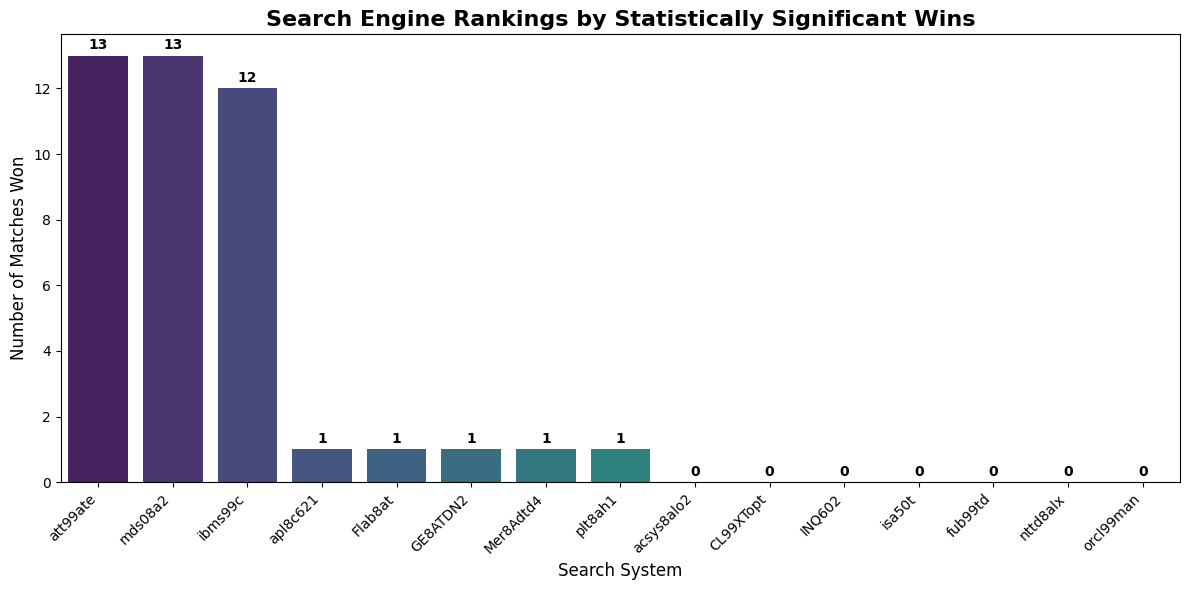

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get a list of all 15 unique systems
systems = pd.concat([df_results['System_A'], df_results['System_B']]).unique()

# 2. Create a dictionary to keep track of everyone's score (starting at 0)
wins = {sys: 0 for sys in systems}

# 3. Calculate the "Wins"
# A win is when the matchup is Significant (p < 0.05) AND they had the better score
for index, row in df_results.iterrows():
    if row['Significant (p<0.05)'] == True:
        # If T-Statistic is positive (+), System A won
        if row['T-Statistic'] > 0:
            wins[row['System_A']] += 1
        # If T-Statistic is negative (-), System B won
        elif row['T-Statistic'] < 0:
            wins[row['System_B']] += 1

# 4. Convert the scores into a neat DataFrame and sort them from Highest to Lowest
df_wins = pd.DataFrame(list(wins.items()), columns=['System', 'Significant_Wins'])
df_wins = df_wins.sort_values(by='Significant_Wins', ascending=False).reset_index(drop=True)

# 5. Draw the Bar Chart
plt.figure(figsize=(12, 6))

# Use Seaborn
sns.barplot(x='System', y='Significant_Wins', data=df_wins, palette='viridis')

# Add titles and labels
plt.title('Search Engine Rankings by Statistically Significant Wins', fontsize=16, fontweight='bold')
plt.xlabel('Search System', fontsize=12)
plt.ylabel('Number of Matches Won', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add the exact number of wins on top of each bar
for index, value in enumerate(df_wins['Significant_Wins']):
    plt.text(index, value + 0.2, str(value), ha='center', fontweight='bold')

# Ensure nothing gets cut off and display the chart
plt.tight_layout()
plt.show()

# Save the chart as an image to your Google Drive for the report!
# plt.savefig('/content/drive/MyDrive/YOUR_FOLDER_PATH_HERE/System_Rankings_Chart.png')

# **Significance Testing Results (P@10)**

**Total Significant Differences:**
Out of the 105 pairs, 43 pairs showed a statistically significant difference (p-value < 0.05).

**Top Performing Systems:**
Based on the head-to-head significance tests, **systems mds08a2 and att99ate** are the top-performing algorithms. They significantly outperformed the majority of the other systems, but showed no significant difference when compared against each other (p = 0.427).

* ibms99c follows as a strong second-tier system, outperforming lower-ranked systems but significantly underperforming compared to the top two.